# Интеграция данных (Вертикальная vs горизонтальная)

In [5]:
data3 = pd.read_csv('issues4.csv', index_col=0)
data3.head()

,Unique id,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Agent,CSAT Score
0,3350ccee-ead7-40fa-80c6-cc7b5e6e345a,Inbound,Returns,Reverse Pickup Enquiry,"August 27, 2023, 08:28:00 AM","August 27, 2023, 08:29:00 AM","August 27, 2023, 12:00:00 AM",Terry Young,5
1,4a88df6e-aafb-477a-bd8e-63ffc34c1a43,Inbound,Returns,Wrong,"December 08, 2023, 03:04:00 PM","August 12, 2023, 03:19:00 PM","August 12, 2023, 12:00:00 AM",Brenda Cox,4
2,7b5dbea2-2370-490a-8fef-4c5f7c52a4cc,Inbound,Returns,Reverse Pickup Enquiry,"August 13, 2023, 12:45:00 PM","August 13, 2023, 01:02:00 PM","August 13, 2023, 12:00:00 AM",Brian Mcguire,5
3,c6d4401e-a4ef-4de0-af68-a8755b928f5f,Inbound,Refund Related,Refund Enquiry,"June 08, 2023, 06:07:00 PM","August 06, 2023, 06:08:00 PM","August 06, 2023, 12:00:00 AM",Dr. Heather Lewis,5
4,423bd17e-e944-4f6e-beff-9c97fa325d9e,Inbound,Returns,Reverse Pickup Enquiry,"April 08, 2023, 10:05:00 PM","August 04, 2023, 10:08:00 PM","August 04, 2023, 12:00:00 AM",Kristin Adams,5


In [8]:
# Переименование столбцов
data2 = data2.rename(columns={
    'channel_name': 'Channel',
    'Reported at': 'Issue_reported_Date',
    'Responded at': 'Issue_responded_Date',
    'Survey responded at': 'Survey_response_Date',
})

# Преобразование дат
data1['Issue_reported_Date'] = pd.to_datetime(data1['Issue_reported_Date'], format='%d/%m/%Y %H:%M')
data1['Issue_responded_Date'] = pd.to_datetime(data1['Issue_responded_Date'], format='%d/%m/%Y %H:%M')
data1['Survey_response_Date'] = pd.to_datetime(data1['Survey_response_Date'], format='%d-%b-%y')
data1.info()
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 28425 entries, 0 to 28424
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    28425 non-null  str           
 1   Channel               28425 non-null  str           
 2   category              28425 non-null  str           
 3   Sub-category          28425 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              22389 non-null  str           
 6   Issue_reported_Date   28425 non-null  datetime64[us]
 7   Issue_responded_Date  28425 non-null  datetime64[us]
 8   Survey_response_Date  28425 non-null  datetime64[us]
 9   Agent_name            28425 non-null  str           
 10  CSAT Score            28425 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(7)
memory usage: 2.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 44339 entries, 0 to 44338
Data columns (tota

In [10]:
data2['Issue_reported_Date'] = pd.to_datetime(data2['Issue_reported_Date'], format='%d %m %Y, %H:%M:%S %p')
data2['Issue_responded_Date'] = pd.to_datetime(data2['Issue_responded_Date'], format='%d %m %Y, %H:%M:%S %p')
data2['Survey_response_Date'] = pd.to_datetime(data2['Survey_response_Date'], format='%d %m %Y')
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 28425 entries, 0 to 28424
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    28425 non-null  str           
 1   Channel               28425 non-null  str           
 2   category              28425 non-null  str           
 3   Sub-category          28425 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              22389 non-null  str           
 6   Issue_reported_Date   28425 non-null  datetime64[us]
 7   Issue_responded_Date  28425 non-null  datetime64[us]
 8   Survey_response_Date  28425 non-null  datetime64[us]
 9   Agent_name            28425 non-null  str           
 10  CSAT Score            28425 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(7)
memory usage: 2.4 MB


In [11]:
data_12 = pd.concat([data1, data2])
data_12.info()

<class 'pandas.DataFrame'>
Index: 72764 entries, 0 to 44338
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    72764 non-null  str           
 1   Channel               72764 non-null  str           
 2   category              72764 non-null  str           
 3   Sub-category          72764 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              66661 non-null  str           
 6   Issue_reported_Date   72764 non-null  datetime64[us]
 7   Issue_responded_Date  72764 non-null  datetime64[us]
 8   Survey_response_Date  72764 non-null  datetime64[us]
 9   Agent_name            72764 non-null  str           
 10  CSAT Score            72764 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(7)
memory usage: 6.7 MB


In [12]:
data3 = data3.rename(columns={
    'Unique id': 'Id',
    'channel_name': 'Channel',
    'Issue_reported at': 'Issue_reported_Date',
    'issue_responded': 'Issue_responded_Date',
    'Agent': 'Agent_name'
})

# Преобразование дат
data3['Issue_reported_Date'] = pd.to_datetime(data3['Issue_reported_Date'])
data3['Issue_responded_Date'] = pd.to_datetime(data3['Issue_responded_Date'])
data3['Survey_response_Date'] = pd.to_datetime(data3['Survey_response_Date'])

# Приведение имён операторов к формату "И. Фамилия"
data3['Agent_name'] = data3['Agent_name'].apply(
    lambda x: x.split()[0][0] + ". " + x.split()[1] if isinstance(x, str) else np.nan
)

data3.info()

<class 'pandas.DataFrame'>
RangeIndex: 13143 entries, 0 to 13142
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    13143 non-null  str           
 1   Channel               13143 non-null  str           
 2   category              13143 non-null  str           
 3   Sub-category          13143 non-null  str           
 4   Issue_reported_Date   13143 non-null  datetime64[us]
 5   Issue_responded_Date  13143 non-null  datetime64[us]
 6   Survey_response_Date  13143 non-null  datetime64[us]
 7   Agent_name            13143 non-null  str           
 8   CSAT Score            13143 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(5)
memory usage: 924.2 KB


/var/folders/nx/cvp4nbcx5075w7wjhzyfgyd40000gn/T/ipykernel_38138/2417346682.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data3['Survey_response_Date'] = pd.to_datetime(data3['Survey_response_Date'])


In [13]:
data_123 = pd.concat([data_12, data3])
data_123.info()

<class 'pandas.DataFrame'>
Index: 85907 entries, 0 to 13142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    85907 non-null  str           
 1   Channel               85907 non-null  str           
 2   category              85907 non-null  str           
 3   Sub-category          85907 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              66661 non-null  str           
 6   Issue_reported_Date   85907 non-null  datetime64[us]
 7   Issue_responded_Date  85907 non-null  datetime64[us]
 8   Survey_response_Date  85907 non-null  datetime64[us]
 9   Agent_name            85907 non-null  str           
 10  CSAT Score            85907 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(7)
memory usage: 7.9 MB


In [14]:
data_123 = pd.concat([data_12, data3])
data_123.info()

<class 'pandas.DataFrame'>
Index: 85907 entries, 0 to 13142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    85907 non-null  str           
 1   Channel               85907 non-null  str           
 2   category              85907 non-null  str           
 3   Sub-category          85907 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              66661 non-null  str           
 6   Issue_reported_Date   85907 non-null  datetime64[us]
 7   Issue_responded_Date  85907 non-null  datetime64[us]
 8   Survey_response_Date  85907 non-null  datetime64[us]
 9   Agent_name            85907 non-null  str           
 10  CSAT Score            85907 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(7)
memory usage: 7.9 MB


In [16]:
orders_data = pd.read_csv('orders.csv', index_col=0)
orders_data = orders_data.rename(columns={'Id': 'Order_id'})
orders_data.head()

,Order_id,order_date_time,Customer_City,Product_category,Item_price
0,53465d50-a568-48a9-b96e-ee2a0524fee8,14/08/2023 18:54,NEW DELHI,Books & General merchandise,144.0
1,57d64c28-e3dc-49bd-8e8a-8e24572c6b59,30/07/2023 21:43,HAJIPUR,Home,445.0
2,55d4e1bb-e148-437f-aa83-3bfbae939155,10/07/2023 21:20,HYDERABAD,LifeStyle,399.0
3,509803e9-4c15-4db4-bbe7-fc1e12b6c6cc,08/08/2023 16:40,JASPUR,Mobile,32999.0
4,5cfbe41f-ffcc-4fcf-8520-94bb61dee14e,07/08/2023 08:29,JHAJJAR,Electronics,1499.0


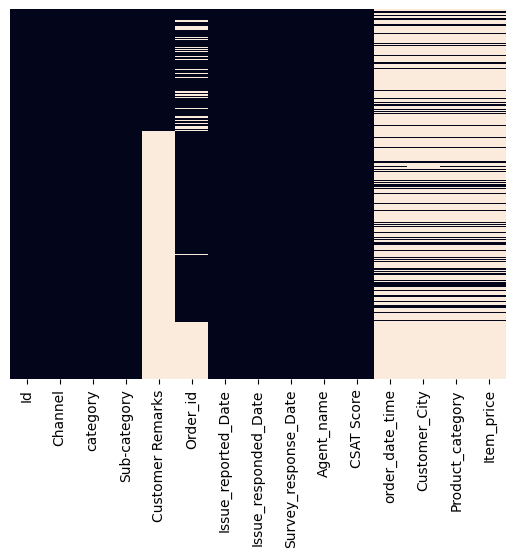

In [17]:
data_with_orders = data_123.merge(orders_data, on='Order_id', how='left')
data_with_orders.head()
sns.heatmap(data_with_orders.isnull(), yticklabels=False, cbar=False)
plt.show()

In [19]:
agent_data = pd.read_csv('agents.csv', index_col=0)
agent_data['Agent_name'] = agent_data['Agent'].apply(
    lambda x: x.split()[0][0] + ". " + x.split()[1] if isinstance(x, str) else np.nan
)
agent_data.head()

,Agent,Supervisor,Manager,Tenure Bucket,Shift,Agent_name
0,Aaron Edwards,Mia Patel,Emily Chen,61-90,Evening,A. Edwards
1,Aaron Romero,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,A. Romero
2,Abigail Gonzalez,Jacob Sato,Jennifer Nguyen,On Job Training,Morning,A. Gonzalez
3,Adam Barnett,Abigail Suzuki,Jennifer Nguyen,On Job Training,Morning,A. Barnett
4,Adam Hammond,Olivia Suzuki,John Smith,31-60,Morning,A. Hammond


In [20]:
agent_data['Agent_name'].value_counts().head(10)

Agent_name
J. Moore       6
A. Brown       4
D. Smith       4
J. Williams    4
K. Martin      4
M. Smith       4
R. Smith       4
A. Harris      3
C. Lewis       3
C. Harris      3
Name: count, dtype: int64

In [21]:
# Временная таблица с количеством возможных соответствий
dup_counts = agent_data['Agent_name'].value_counts().rename('dup_count')
data_with_agent_counts = data_with_orders.merge(dup_counts, how='left', left_on='Agent_name', right_index=True)
data_with_agent_counts['dup_count'].value_counts()

dup_count
1    68749
2    11326
3     3695
4     1843
6      294
Name: count, dtype: int64

In [22]:
# Оставляем только те строки, где имя агента уникально в справочнике
data_with_agent_counts['Agent_name_clean'] = data_with_agent_counts['Agent_name'].where(
    data_with_agent_counts['dup_count'] == 1, np.nan
)

In [23]:
data_with_agents = data_with_agent_counts.merge(
    agent_data, how='left', left_on='Agent_name_clean', right_on='Agent_name'
)
data_with_agents.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    85907 non-null  str           
 1   Channel               85907 non-null  str           
 2   category              85907 non-null  str           
 3   Sub-category          85907 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              66661 non-null  str           
 6   Issue_reported_Date   85907 non-null  datetime64[us]
 7   Issue_responded_Date  85907 non-null  datetime64[us]
 8   Survey_response_Date  85907 non-null  datetime64[us]
 9   Agent_name_x          85907 non-null  str           
 10  CSAT Score            85907 non-null  int64         
 11  order_date_time       16951 non-null  str           
 12  Customer_City         16817 non-null  str           
 13  Product_category      16933

In [24]:
data_with_agents = data_with_agent_counts.merge(
    agent_data, how='left', left_on='Agent_name_clean', right_on='Agent_name'
)
data_with_agents.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    85907 non-null  str           
 1   Channel               85907 non-null  str           
 2   category              85907 non-null  str           
 3   Sub-category          85907 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              66661 non-null  str           
 6   Issue_reported_Date   85907 non-null  datetime64[us]
 7   Issue_responded_Date  85907 non-null  datetime64[us]
 8   Survey_response_Date  85907 non-null  datetime64[us]
 9   Agent_name_x          85907 non-null  str           
 10  CSAT Score            85907 non-null  int64         
 11  order_date_time       16951 non-null  str           
 12  Customer_City         16817 non-null  str           
 13  Product_category      16933

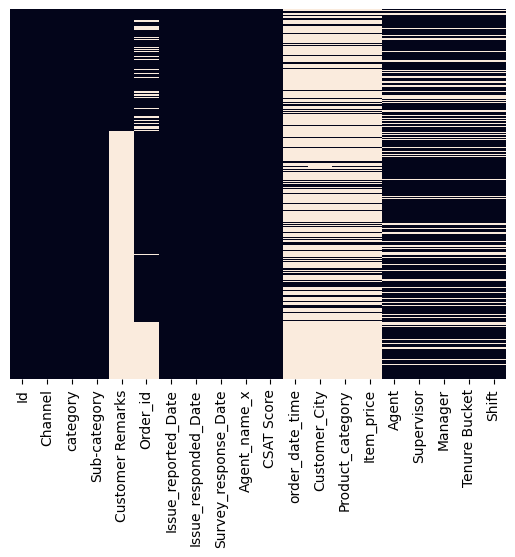

In [25]:
data_with_agents = data_with_agents.drop(
    ['dup_count', 'Agent_name_clean', 'Agent_name_y'], axis=1, errors='ignore'
)
sns.heatmap(data_with_agents.isnull(), yticklabels=False, cbar=False)
plt.show()

In [26]:
data_with_agents.head()

,Id,Channel,category,Sub-category,Customer Remarks,Order_id,Issue_reported_Date,Issue_responded_Date,Survey_response_Date,Agent_name_x,CSAT Score,order_date_time,Customer_City,Product_category,Item_price,Agent,Supervisor,Manager,Tenure Bucket,Shift
0,8c910188-c387-4a1b-8d90-24379ec8c047,Inbound,Returns,Reverse Pickup Enquiry,Very happy,NaN,2023-08-04 19:10:00,2023-08-04 19:13:00,2023-08-04,J. Blackwell,1,NaN,NaN,NaN,NaN,James Blackwell,Jackson Park,William Kim,On Job Training,Evening
1,99d5ee06-8d2a-4754-bd17-ed235c70bf33,Inbound,Returns,Return request,Thoda jalfi replacement approve kijiye mera,89e6448f-9a48-4892-a09c-b47e0d8a87fe,2023-08-18 09:11:00,2023-08-18 09:18:00,2023-08-18,M. Wilson,4,14/08/2023 00:42,NAYAGARH,Electronics,1499.0,Mark Wilson,Scarlett Chen,John Smith,0-30,Morning
2,336020c5-dc97-488f-8f16-ed33ed04e5fc,Inbound,Returns,Damaged,Technician not visit the RO and without visit ...,15476f9a-35cc-4f33-ae33-8d9cd6ecb1a6,2023-08-22 07:15:00,2023-08-22 08:15:00,2023-08-22,A. Smith,5,NaN,NaN,NaN,NaN,Anthony Smith,Mia Patel,John Smith,>90,Morning
3,22c5643c-3d54-487c-8863-c57e198a70be,Inbound,Returns,Fraudulent User,madam ne mera problem solve kar Diya hai . t...,NaN,2023-08-14 09:21:00,2023-08-14 09:27:00,2023-08-14,A. Berry,5,NaN,NaN,NaN,NaN,Amy Berry,Elijah Yamaguchi,John Smith,>90,Evening
4,abd330a8-f3e2-4b7a-b14a-4ed35c4ec023,Inbound,Returns,Fraudulent User,Gjjjzjxgxteuhxgxe5xhxh,NaN,2023-08-03 08:18:00,2023-08-03 08:23:00,2023-08-03,S. Taylor,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Задания для самостоятельного решения

## Задание 1. Проверка дубликатов при вертикальном объединении

In [27]:
# Проверяем дубликаты по столбцу Id (уникальный идентификатор записи)
print(f"Строк до дедупликации: {len(data_123)}")
dups = data_123.duplicated(subset='Id')
print(f"Дубликатов по Id: {dups.sum()}")

# Проверяем дубликаты по всем столбцам
dups_all = data_123.duplicated()
print(f"Полных дубликатов: {dups_all.sum()}")

# Удаляем дубликаты, если есть
data_123_clean = data_123.drop_duplicates(subset='Id')
print(f"Строк после дедупликации: {len(data_123_clean)}")


Строк до дедупликации: 85907
Дубликатов по Id: 0
Полных дубликатов: 0
Строк после дедупликации: 85907


## Задание 2. Распределение признаков до горизонтального объединения

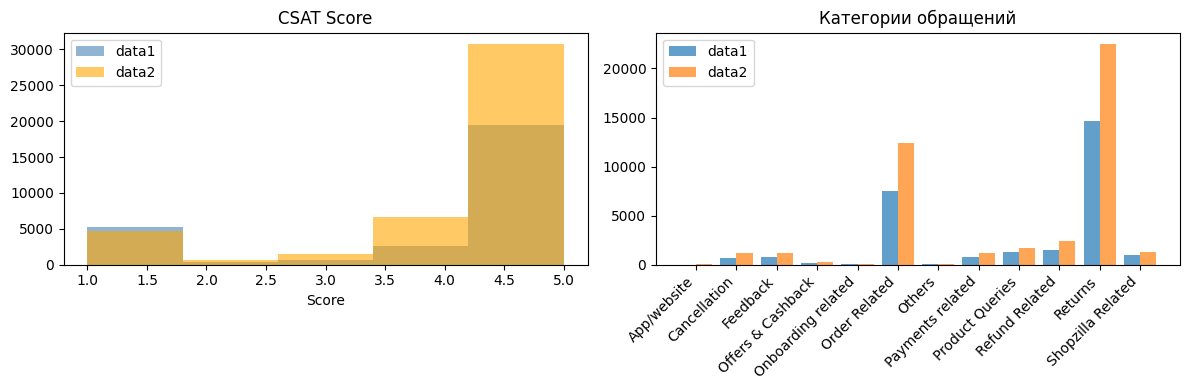

In [28]:
# Сравниваем шкалы признаков data1 и data2 до concat
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CSAT Score
axes[0].hist(data1['CSAT Score'], bins=5, alpha=0.6, label='data1', color='steelblue')
axes[0].hist(data2['CSAT Score'], bins=5, alpha=0.6, label='data2', color='orange')
axes[0].set_title('CSAT Score'); axes[0].set_xlabel('Score'); axes[0].legend()

# Категории — кол-во уникальных
cat_counts1 = data1['category'].value_counts()
cat_counts2 = data2['category'].value_counts()
all_cats = sorted(set(cat_counts1.index) | set(cat_counts2.index))
x = range(len(all_cats))
w = 0.4
axes[1].bar([i-w/2 for i in x], [cat_counts1.get(c,0) for c in all_cats], width=w, label='data1', alpha=0.7)
axes[1].bar([i+w/2 for i in x], [cat_counts2.get(c,0) for c in all_cats], width=w, label='data2', alpha=0.7)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(all_cats, rotation=45, ha='right')
axes[1].set_title('Категории обращений'); axes[1].legend()

plt.tight_layout(); plt.show()
# Шкалы CSAT Score соотносимы (1-5), категории перекрываются


## Задание 3. Пропуски после объединения с orders — не ошибка

In [29]:
# Проверка 1: сколько Order_id вообще есть в data_123
has_order = data_123['Order_id'].notna().sum()
print(f"Обращений с Order_id: {has_order} из {len(data_123)}")

# Проверка 2: сколько Order_id из data_123 есть в orders_data
matched = data_123['Order_id'].isin(orders_data['Order_id']).sum()
print(f"Order_id совпали с orders: {matched}")

# Проверка 3: несколько случайных Order_id без совпадения
missing_orders = data_123.loc[data_123['Order_id'].notna() &
                               ~data_123['Order_id'].isin(orders_data['Order_id']), 'Order_id']
print(f"Order_id без совпадения в orders: {len(missing_orders)}")
print("Примеры:", missing_orders.head(3).tolist())

# Проверка 4: убеждаемся, что у найденных совпадений данные заполнены
sample_matched = data_with_orders.loc[data_with_orders['Order_id'].isin(orders_data['Order_id'].head(5))]
print(f"\nЗаполненность Customer_City у совпадений: {sample_matched['Customer_City'].notna().mean():.0%}")
# Вывод: пропуски — следствие отсутствия заказов в orders, а не ошибки join


Обращений с Order_id: 66661 из 85907
Order_id совпали с orders: 16951
Order_id без совпадения в orders: 49710
Примеры: ['15476f9a-35cc-4f33-ae33-8d9cd6ecb1a6', 'e4e66d36-19af-4193-aaf9-c089792009a3', '6ae68dfc-2d1b-492a-b4dc-187924f8e787']

Заполненность Customer_City у совпадений: nan%


## Задание 4. Разные виды соединений (merge)

In [30]:
# inner — только строки с совпадающим Order_id
inner = data_123.merge(orders_data, on='Order_id', how='inner')
print(f"inner:  {inner.shape}  (только обращения с заказами)")

# left — все обращения, заказы где есть (наш основной вариант)
left = data_123.merge(orders_data, on='Order_id', how='left')
print(f"left:   {left.shape}  (все обращения + данные заказов где есть)")

# right — все заказы + обращения где есть
right = data_123.merge(orders_data, on='Order_id', how='right')
print(f"right:  {right.shape}  (все заказы + обращения где есть)")

# outer — всё
outer = data_123.merge(orders_data, on='Order_id', how='outer')
print(f"outer:  {outer.shape}  (все строки из обеих таблиц)")

print("\nПропуски Customer_City по типам join:")
for name, df in [('inner', inner), ('left', left), ('right', right), ('outer', outer)]:
    pct = df['Customer_City'].isna().mean()
    print(f"  {name}: {pct:.1%}")


inner:  (16951, 15)  (только обращения с заказами)
left:   (85907, 15)  (все обращения + данные заказов где есть)
right:  (86070, 15)  (все заказы + обращения где есть)
outer:  (155026, 15)  (все строки из обеих таблиц)

Пропуски Customer_City по типам join:
  inner: 0.8%
  left: 80.4%
  right: 0.8%
  outer: 44.9%


## Задание 5. merge и join в pandas — ключевые отличия

In [31]:
# merge — гибкое объединение по произвольному столбцу/нескольким столбцам
# join  — объединение по индексу (удобно, когда ключ = индекс)

# Пример join через индекс
agents_idx = agent_data.set_index('Agent_name')
data_idx = data_with_orders.set_index('Agent_name_x' if 'Agent_name_x' in data_with_orders.columns else 'Agent_name')

joined = data_idx.join(agents_idx, how='left', rsuffix='_agent')
print("join по индексу:", joined.shape)
print(joined[['category', 'Agent', 'Supervisor']].head(3))

# Ключевые параметры merge:
# on        — столбец(ы) для объединения
# how       — тип: inner/left/right/outer/cross
# left_on / right_on — разные имена ключей в таблицах
# suffixes  — суффиксы при конфликте имён столбцов
# validate  — проверка вида соединения ('1:1', '1:m', 'm:1', 'm:m')
print("\nПример validate m:1 (несколько обращений на один заказ):")
try:
    data_123.merge(orders_data, on='Order_id', how='inner', validate='m:1')
    print("OK — каждый Order_id в orders встречается один раз")
except Exception as e:
    print(e)


join по индексу: (111622, 19)
             category            Agent     Supervisor
Agent_name                                           
J. Blackwell  Returns  James Blackwell   Jackson Park
M. Wilson     Returns      Mark Wilson  Scarlett Chen
A. Smith      Returns    Anthony Smith      Mia Patel

Пример validate m:1 (несколько обращений на один заказ):
Merge keys are not unique in right dataset; not a many-to-one merge

Duplicates in right:
                             Order_id
5773bba7-ab71-4dae-a9db-18236b9c4470
55291d22-4884-4928-890f-b1f247767bfc
5f51c139-e092-4fb5-a6d6-e534b47fd40f
56c37aa1-e8cf-4a69-95ba-4147b09a9287
513470f8-26a9-4771-afbb-196bb51e0f72 ...


## Задание 6. Формат дат strftime

In [32]:
# strftime — форматирование datetime в строку
# strptime — парсинг строки в datetime (используется в pd.to_datetime(format=...))

# Основные коды:
# %d — день (01-31)    %m — месяц (01-12)    %Y — год (4 цифры)
# %H — час (00-23)     %M — минуты           %S — секунды
# %b — сокр. месяц (Jan/Feb)   %B — полный месяц   %y — год (2 цифры)

# Примеры форматов из нашего датасета
dates = data_123['Issue_reported_Date'].head(3)

print("Оригинальный формат:")
print(dates.values)

print("\nstrftime примеры:")
print(dates.dt.strftime('%d/%m/%Y %H:%M'))      # как в data1
print(dates.dt.strftime('%d %m %Y, %H:%M:%S %p'))  # как в data2
print(dates.dt.strftime('%B %d, %Y, %H:%M:%S %p'))  # как в data3
print(dates.dt.strftime('%d-%b-%y'))             # как Survey_response_Date в data1

# Применение: создание новых временных признаков
data_123['report_month'] = data_123['Issue_reported_Date'].dt.strftime('%Y-%m')
print("\nОбращения по месяцам:")
print(data_123['report_month'].value_counts().sort_index())


Оригинальный формат:
['2023-08-04T19:10:00.000000' '2023-08-18T09:11:00.000000'
 '2023-08-22T07:15:00.000000']

strftime примеры:
0    04/08/2023 19:10
1    18/08/2023 09:11
2    22/08/2023 07:15
Name: Issue_reported_Date, dtype: str
0    04 08 2023, 19:10:00 PM
1    18 08 2023, 09:11:00 AM
2    22 08 2023, 07:15:00 AM
Name: Issue_reported_Date, dtype: str
0    August 04, 2023, 19:10:00 PM
1    August 18, 2023, 09:11:00 AM
2    August 22, 2023, 07:15:00 AM
Name: Issue_reported_Date, dtype: str
0    04-Aug-23
1    18-Aug-23
2    22-Aug-23
Name: Issue_reported_Date, dtype: str

Обращения по месяцам:
report_month
2023-01       39
2023-02      158
2023-03     1437
2023-04     1438
2023-05       60
2023-06       44
2023-07      297
2023-08    80706
2023-09       47
2023-10       60
2023-11      173
2023-12     1448
Name: count, dtype: int64
